# Sistem Klasifikasi Obesitas

## Menentukan Pertanyaan Bisnis

Pertanyaan 1 ...

Pertanyaan 2...

## Data Wrangling

### Gathering Data

*Import Library*

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15, 20)

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 50)

np.set_printoptions(precision=3)

*Loading Data*

In [2]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [3]:
# Melihat 5 data teratas
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
# # Melihat 5 data terbawah
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20.977,Female,1.711,131.409,Sometimes,yes,3.0,3.0,no,no,1.728,yes,1.676,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.983,Female,1.749,133.743,Sometimes,yes,3.0,3.0,no,no,2.005,yes,1.341,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524,Female,1.752,133.689,Sometimes,yes,3.0,3.0,no,no,2.054,yes,1.414,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.362,Female,1.739,133.347,Sometimes,yes,3.0,3.0,no,no,2.852,yes,1.139,0.586,Sometimes,Public_Transportation,Obesity_Type_III
2110,23.665,Female,1.739,133.473,Sometimes,yes,3.0,3.0,no,no,2.864,yes,1.026,0.714,Sometimes,Public_Transportation,Obesity_Type_III


####

### Assesing Data

*Melihat informasi umum dan bentuk data*

In [5]:
# Melihat informasi umum dan tipe data
df.info()

print("="*50)

# Melihat bentuk data
df.shape
baris, kolom = df.shape
print(f"Jumlah baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

*Mengecek Missing Value*

In [6]:
# Mengecek missing value di setiap kolom
print("[MISSING VALUES]")
df.isnull().sum()


[MISSING VALUES]


Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

*Mengecek Data Duplikat*

In [7]:
# Menghitung jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 24


*Mengecek Statistik Deskriptif Dataset*

In [8]:
df.describe(include='all')

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.000,2111,2111.000,2111.000,2111,2111,2111.000,2111.000,2111,2111,2111.000,2111,2111.000,2111.000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.313,NaN,1.702,86.586,NaN,NaN,2.419,2.686,NaN,NaN,2.008,NaN,1.010,0.658,NaN,NaN,NaN
std,6.346,NaN,0.093,26.191,NaN,NaN,0.534,0.778,NaN,NaN,0.613,NaN,0.851,0.609,NaN,NaN,NaN
min,14.000,NaN,1.450,39.000,NaN,NaN,1.000,1.000,NaN,NaN,1.000,NaN,0.000,0.000,NaN,NaN,NaN
25%,19.947,NaN,1.630,65.473,NaN,NaN,2.000,2.659,NaN,NaN,1.585,NaN,0.125,0.000,NaN,NaN,NaN
50%,22.778,NaN,1.700,83.000,NaN,NaN,2.386,3.000,NaN,NaN,2.000,NaN,1.000,0.625,NaN,NaN,NaN
75%,26.000,NaN,1.768,107.431,NaN,NaN,3.000,3.000,NaN,NaN,2.477,NaN,1.667,1.000,NaN,NaN,NaN


## Data Cleaning

*Menghilangkan Data Duplikat*

In [9]:
# Menghapus Seluruh Data Duplikat Langsung pada df
df.drop_duplicates(inplace=True)

In [10]:
# Mengecek jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 0


*Menyesuaikan Tipe Data*

In [11]:
# Mengubah semua kolom numerik kecuali 'Height' dan 'Weight' menjadi integer untuk menjaga konsistensi data
for column in df.columns:
    # Mengecualikan kolom Height dan Weight
    if df[column].dtype == "float64" and column not in ["Height", "Weight"]:
        # Bulatkan dulu (round), baru jadikan integer
        df[column] = df[column].round().astype('int64')

In [12]:
# Mengecek Kembali Tipe Data
df.dtypes

Age                                 int64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                                int64
NCP                                 int64
SCC                                object
SMOKE                              object
CH2O                                int64
family_history_with_overweight     object
FAF                                 int64
TUE                                 int64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

*Rekategorisasi Target*

In [13]:
# Cek Distribusi kolom target lama
print("Distribusi kolom lama:")
print(df['NObeyesdad'].value_counts())
print("=" * 50)

# Dictionary pemetaan untuk 4 kelas baru
mapping_obesitas = {
    'Insufficient_Weight': 'Underweight',
    'Normal_Weight': 'Normal',
    'Overweight_Level_I': 'Overweight',
    'Overweight_Level_II': 'Overweight',
    'Obesity_Type_I': 'Obesity',
    'Obesity_Type_II': 'Obesity',
    'Obesity_Type_III': 'Obesity'
}

# Membuat Kolom Baru yang Akan Menampung Kelas Baru dengan Nama Weight_Status
df['Weight_Status'] = df['NObeyesdad'].replace(mapping_obesitas)

# Tampilkan kolom lama dan baru
print("\nMengecek kolom target lama dan baru:")
print(df[['NObeyesdad', 'Weight_Status']].sample(5))
print("=" * 50)

# Cek distribusi kolom target baru
print("\nDistribusi kolom baru:")
print(df['Weight_Status'].value_counts())

Distribusi kolom lama:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64

Mengecek kolom target lama dan baru:
            NObeyesdad Weight_Status
223      Normal_Weight        Normal
1676   Obesity_Type_II       Obesity
1766   Obesity_Type_II       Obesity
1940  Obesity_Type_III       Obesity
1313    Obesity_Type_I       Obesity

Distribusi kolom baru:
Weight_Status
Obesity        972
Overweight     566
Normal         282
Underweight    267
Name: count, dtype: int64


In [14]:
df

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Weight_Status
0,21,Female,1.620,64.000,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal_Weight,Normal
1,21,Female,1.520,56.000,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,Normal
2,23,Male,1.800,77.000,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal_Weight,Normal
3,27,Male,1.800,87.000,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight_Level_I,Overweight
4,22,Male,1.780,89.800,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,21,Female,1.711,131.409,Sometimes,yes,3,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Obesity_Type_III,Obesity
2107,22,Female,1.749,133.743,Sometimes,yes,3,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Obesity_Type_III,Obesity
2108,23,Female,1.752,133.689,Sometimes,yes,3,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Obesity_Type_III,Obesity
2109,24,Female,1.739,133.347,Sometimes,yes,3,3,no,no,3,yes,1,1,Sometimes,Public_Transportation,Obesity_Type_III,Obesity


## EDA

*Cek Outlier di Fitur numerik*

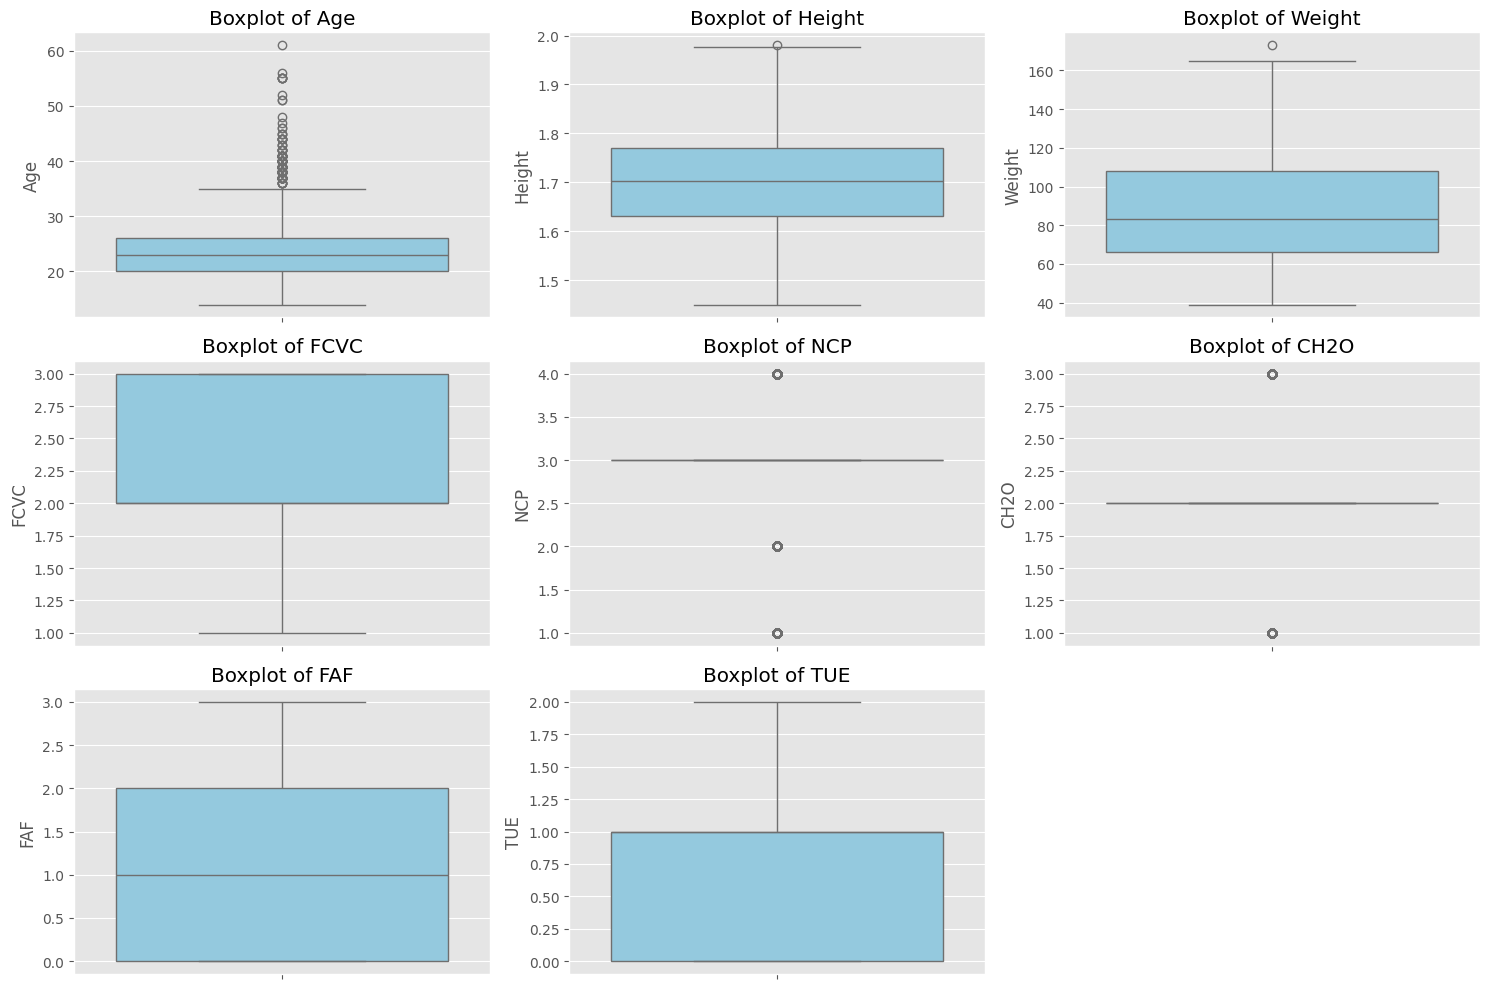

In [15]:
# Memilih hanya kolom yang bertipe numerik (integer & float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Mengatur ukuran kanvas / figure
plt.figure(figsize=(15, 10))

# Looping untuk membuat boxplot pada setiap kolom numerik
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i) # Menyesuaikan jumlah grid (3 kolom per baris)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()